<a href="https://colab.research.google.com/github/PandeyChhaya/6CS012-AI-ML/blob/main/2522725_ChhayaPandey_ImageClassification_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
print(os.listdir('/content/'))

['.config', 'Test', 'Training', 'fruits_20_clean.zip', 'sample_data']


In [3]:
TRAIN_DIR = '/content/Training'
TEST_DIR  = '/content/Test'
print("Paths set!")

Paths set!


In [5]:
import os

TRAIN_DIR = '/content/Training'
TEST_DIR  = '/content/Test'

classes = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(classes)

print(f"Number of classes: {NUM_CLASSES}")
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f"{cls}: {len(images)} images")

Number of classes: 20
Apple Granny Smith 1: 492 images
Apple Red 1: 492 images
Avocado 1: 427 images
Banana 1: 490 images
Blueberry 1: 462 images
Cherry 1: 492 images
Cocos 1: 490 images
Grape Blue 1: 984 images
Kiwi 1: 466 images
Lemon 1: 492 images
Mango 1: 490 images
Orange 1: 479 images
Papaya 1: 492 images
Peach 1: 492 images
Pear 1: 492 images
Pineapple 1: 490 images
Pomegranate 1: 492 images
Raspberry 1: 490 images
Strawberry 1: 492 images
Watermelon 1: 475 images


In [6]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2

TRAIN_DIR = '/content/Training'
TEST_DIR  = '/content/Test'
classes = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(classes)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('Classes:', NUM_CLASSES)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Classes: 20


Installing and Importing libraries


In [7]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Step 3: Data Understanding, Analysis & Visualization

In [8]:

classes = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(classes)
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {classes}')

train_counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes]
test_counts  = [len(os.listdir(os.path.join(TEST_DIR,  c))) for c in classes]

print(f'\nTotal training images : {sum(train_counts)}')
print(f'Total test images     : {sum(test_counts)}')

Number of classes: 20
Classes: ['Apple Granny Smith 1', 'Apple Red 1', 'Avocado 1', 'Banana 1', 'Blueberry 1', 'Cherry 1', 'Cocos 1', 'Grape Blue 1', 'Kiwi 1', 'Lemon 1', 'Mango 1', 'Orange 1', 'Papaya 1', 'Peach 1', 'Pear 1', 'Pineapple 1', 'Pomegranate 1', 'Raspberry 1', 'Strawberry 1', 'Watermelon 1']

Total training images : 10171
Total test images     : 3404


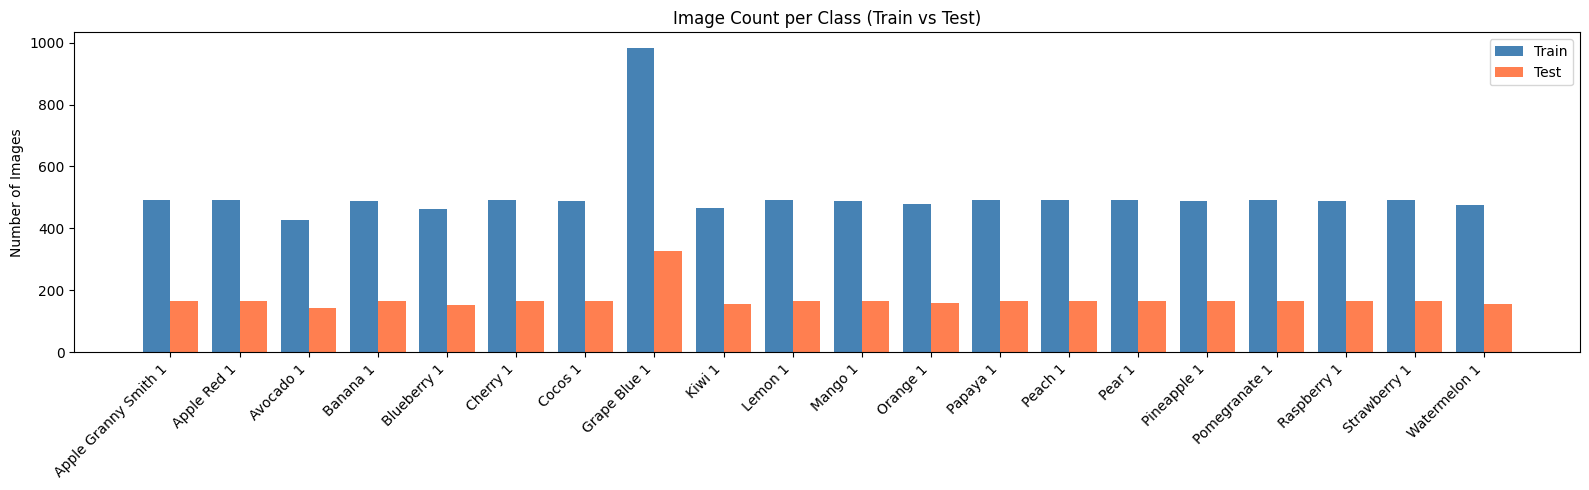

In [9]:
# Class distribution bar chart
x = np.arange(NUM_CLASSES)
width = 0.4
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width/2, train_counts, width, label='Train', color='steelblue')
ax.bar(x + width/2, test_counts,  width, label='Test',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_title('Image Count per Class (Train vs Test)')
ax.set_ylabel('Number of Images')
ax.legend()
plt.tight_layout()
plt.show()

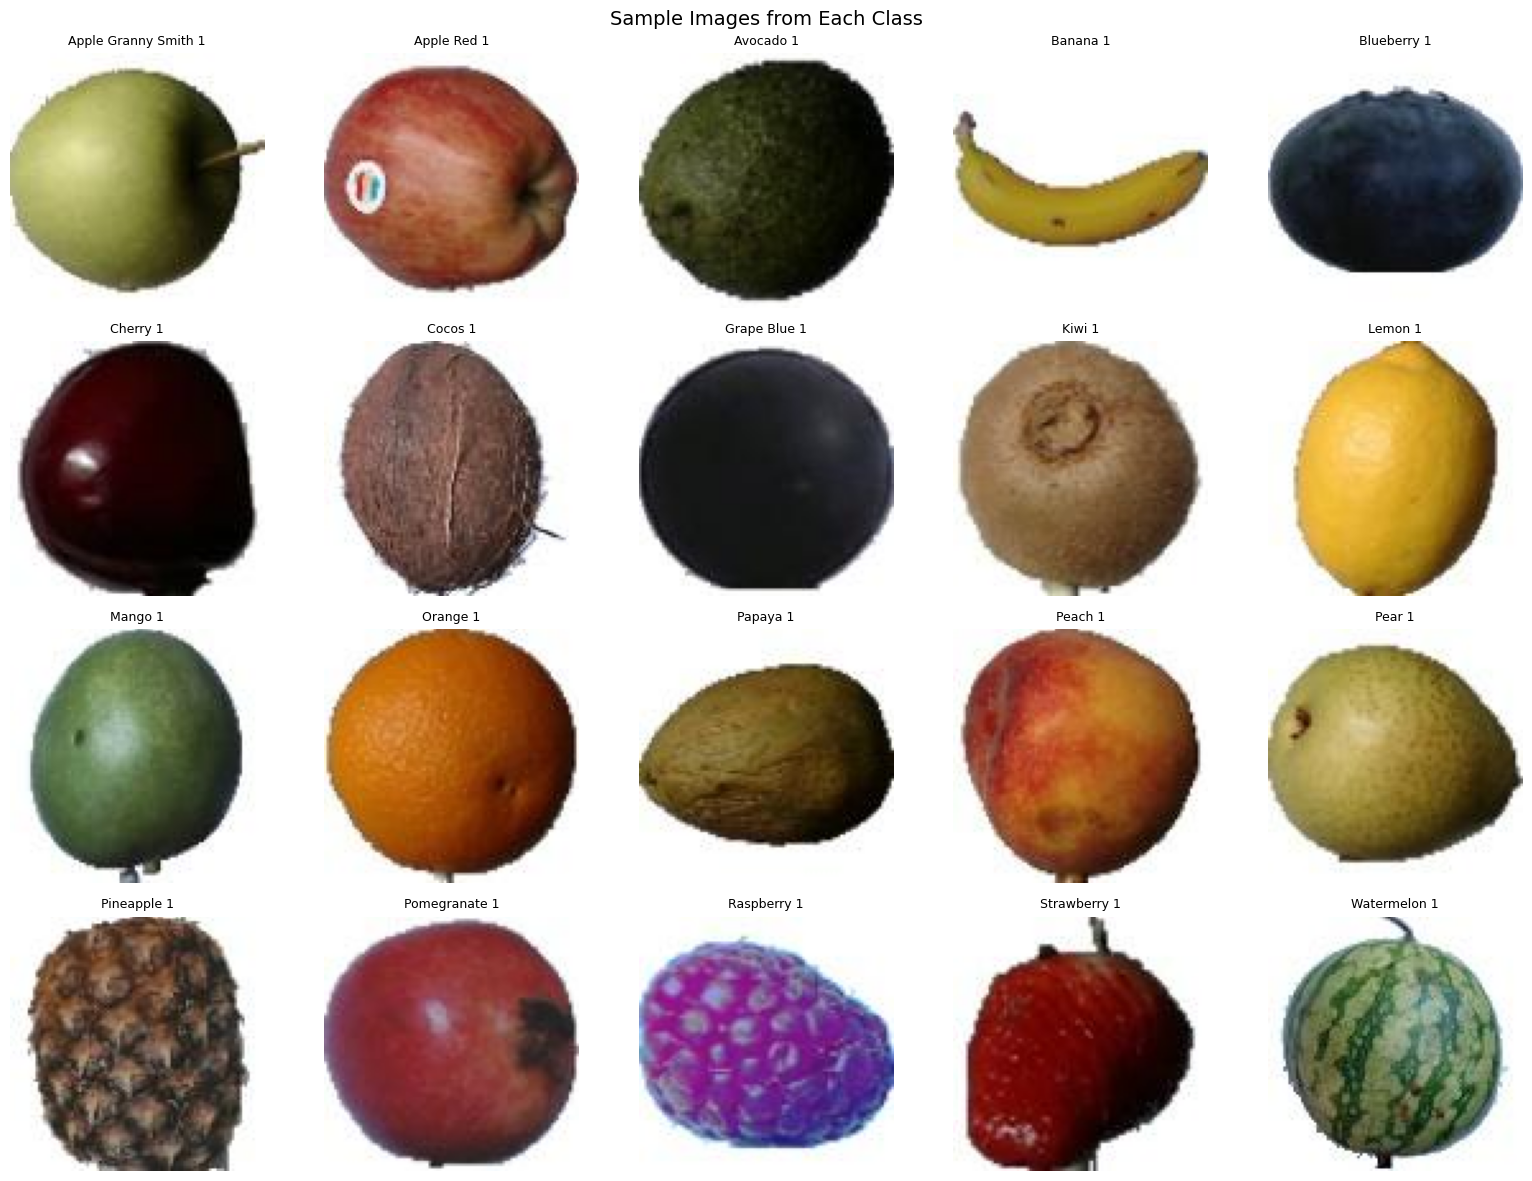

In [10]:
# Display one sample image per class
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
axes = axes.flatten()
for i, cls in enumerate(classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

---
 Step 4: Data Preprocessing & Augmentation

In [11]:
IMG_SIZE   = (64, 64)   # resize all images to 64x64
BATCH_SIZE = 32

# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    validation_split=0.2   # 80/20 split from training folder
)

# Test generator – only rescale, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print('Train batches:', len(train_gen))
print('Val   batches:', len(val_gen))
print('Test  batches:', len(test_gen))

Found 8143 images belonging to 20 classes.
Found 2028 images belonging to 20 classes.
Found 3404 images belonging to 20 classes.
Train batches: 255
Val   batches: 64
Test  batches: 107


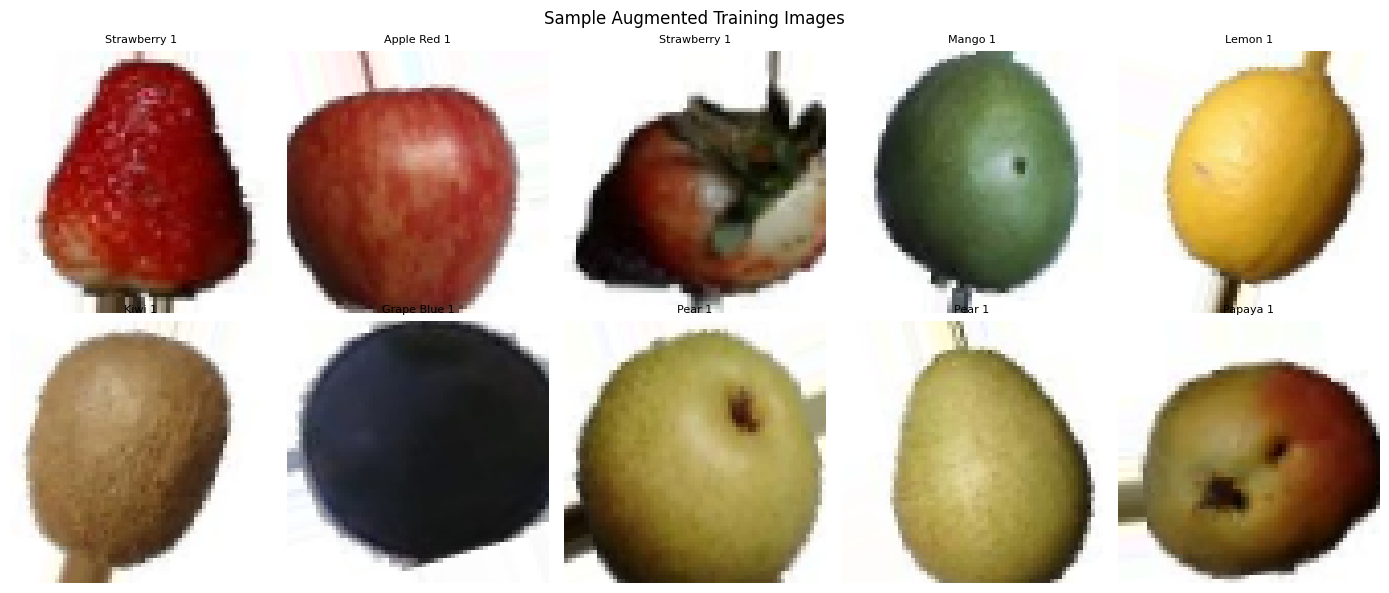

In [12]:
# Visualize augmented images
sample_batch, sample_labels = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch[i])
    label_idx = np.argmax(sample_labels[i])
    ax.set_title(classes[label_idx], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Augmented Training Images')
plt.tight_layout()
plt.show()

PART A – Section 1: Baseline CNN (from scratch)

In [13]:
def build_baseline_cnn(num_classes):
    model = models.Sequential([
        # --- Conv Block 1 ---
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
        layers.MaxPooling2D(2,2),
        # --- Conv Block 2 ---
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        # --- Conv Block 3 ---
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        # --- Flatten ---
        layers.Flatten(),
        # --- FCN Layers ---
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        # --- Output ---
        layers.Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,233,108 (8.52 MB)

 Trainable params: 2,233,108 (8.52 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

start = time.time()
baseline_history = baseline_model.fit(
    train_gen, validation_data=val_gen,
    epochs=30, callbacks=callbacks
)
baseline_time = time.time() - start
print(f'\nBaseline training time: {baseline_time:.1f}s')

Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.7468 - loss: 0.7580 - val_accuracy: 0.9729 - val_loss: 0.1135 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.9493 - loss: 0.1509 - val_accuracy: 0.9753 - val_loss: 0.1069 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.9671 - loss: 0.0951 - val_accuracy: 0.9906 - val_loss: 0.0458 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.9853 - loss: 0.0408 - val_accuracy: 0.9610 - val_loss: 0.0857 - learning_rate: 0.0010
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.9819 - loss: 0.0549 - val_accuracy: 0.9980 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.9869 - loss: 0.0412 - val_accuracy: 0.9758 - val_loss: 0.0797 - learning_rate: 0.0010
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.9686 - l

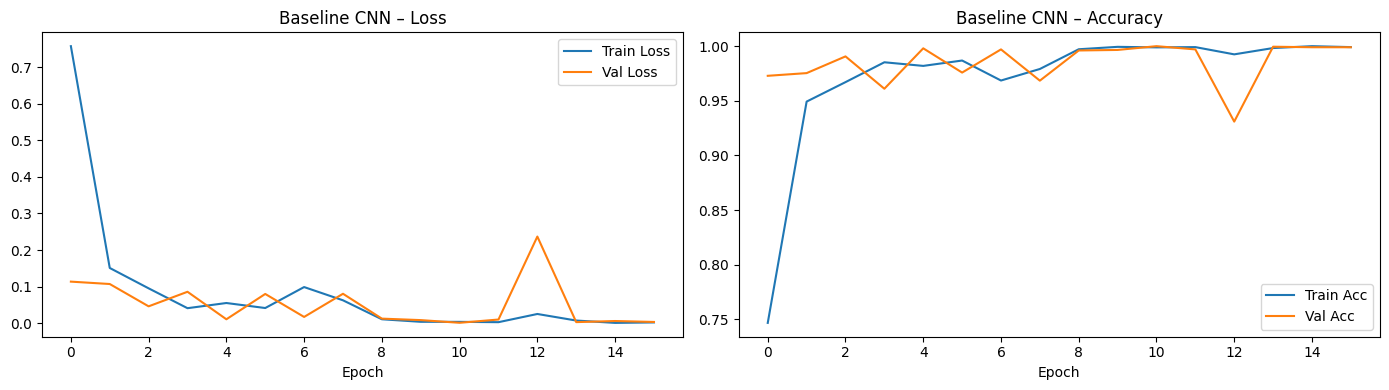

In [15]:
# Plot training curves – Baseline
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history['loss'],     label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'{title} – Loss')
    ax1.set_xlabel('Epoch'); ax1.legend()

    ax2.plot(history.history['accuracy'],     label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title(f'{title} – Accuracy')
    ax2.set_xlabel('Epoch'); ax2.legend()
    plt.tight_layout(); plt.show()

plot_history(baseline_history, 'Baseline CNN')


Baseline CNN – Test Loss: 0.0210 | Test Accuracy: 0.9894
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step

Classification Report:
                      precision    recall  f1-score   support

Apple Granny Smith 1       1.00      1.00      1.00       164
         Apple Red 1       0.82      1.00      0.90       164
           Avocado 1       1.00      1.00      1.00       143
            Banana 1       1.00      1.00      1.00       166
         Blueberry 1       1.00      1.00      1.00       154
            Cherry 1       1.00      1.00      1.00       164
             Cocos 1       1.00      1.00      1.00       166
        Grape Blue 1       1.00      1.00      1.00       328
              Kiwi 1       1.00      1.00      1.00       156
             Lemon 1       1.00      1.00      1.00       164
             Mango 1       1.00      1.00      1.00       166
            Orange 1       1.00      1.00      1.00       160
            Papaya 1       1.00      1.00      1.00       164
       

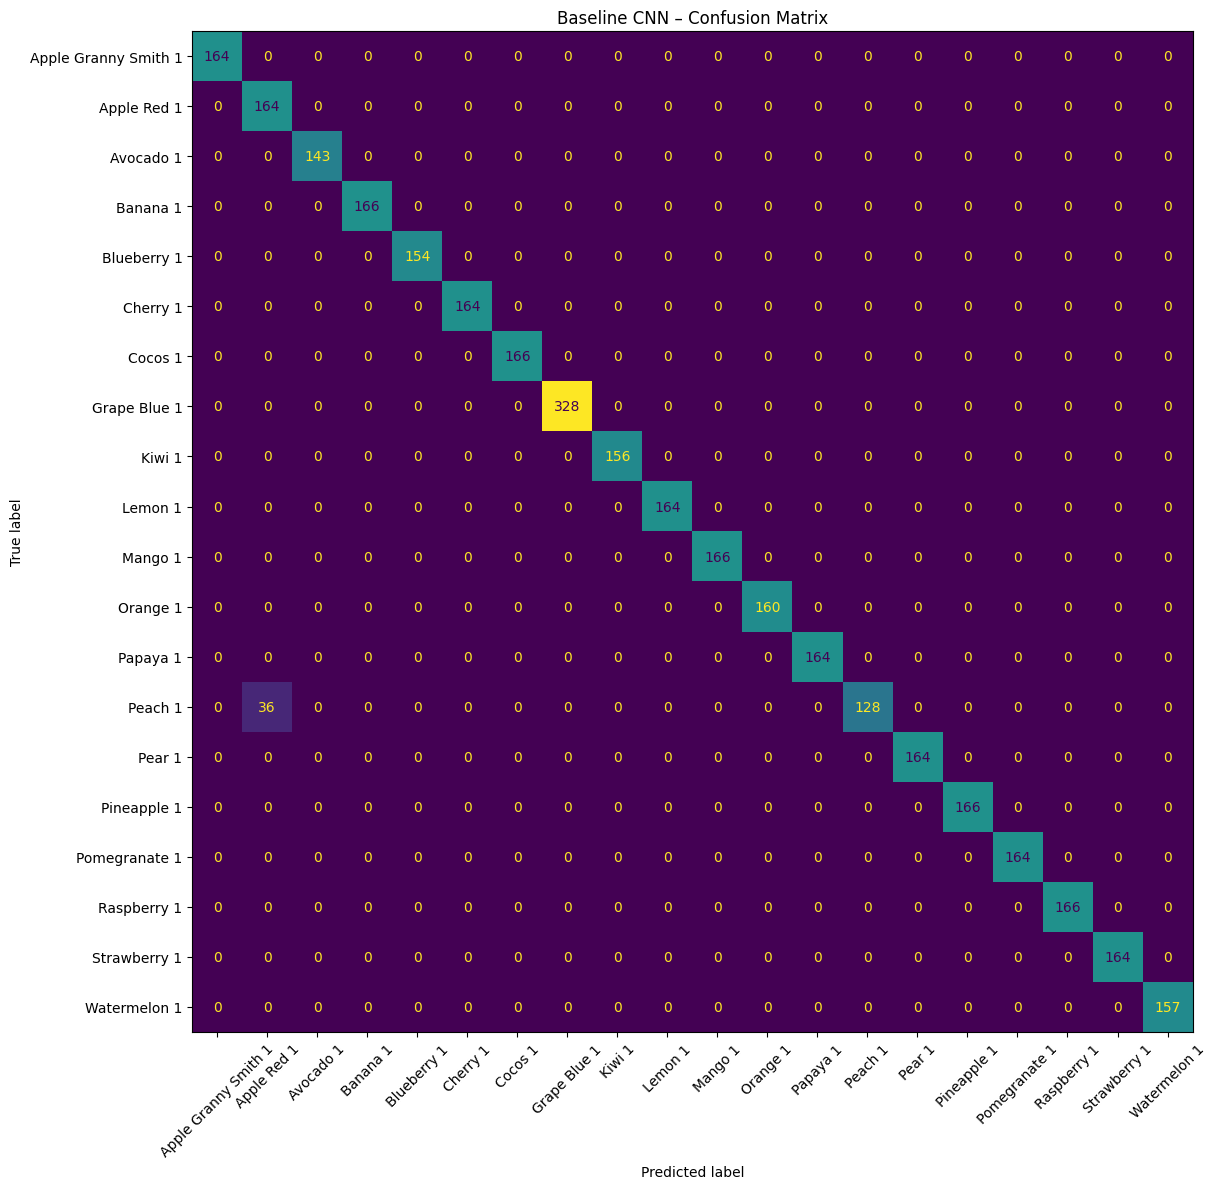

In [16]:
# Evaluate Baseline
def evaluate_model(model, test_gen, model_name):
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f'\n{model_name} – Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}')

    test_gen.reset()
    y_pred = np.argmax(model.predict(test_gen), axis=1)
    y_true = test_gen.classes

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(14, 12))
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f'{model_name} – Confusion Matrix')
    plt.tight_layout(); plt.show()
    return acc

baseline_acc = evaluate_model(baseline_model, test_gen, 'Baseline CNN')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


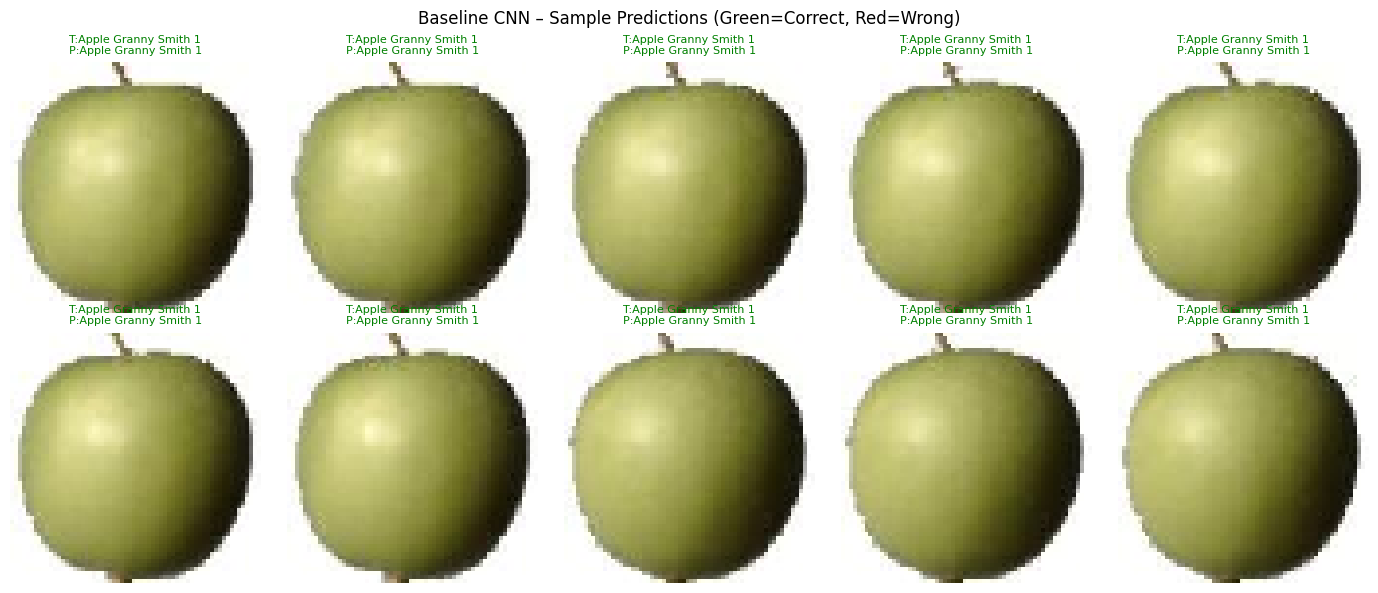

In [17]:
# Sample inference – show predictions on individual images
test_gen.reset()
sample_imgs, sample_lbls = next(test_gen)
preds = baseline_model.predict(sample_imgs[:10])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i])
    true_cls  = classes[np.argmax(sample_lbls[i])]
    pred_cls  = classes[np.argmax(preds[i])]
    color = 'green' if true_cls == pred_cls else 'red'
    ax.set_title(f'T:{true_cls}\nP:{pred_cls}', color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('Baseline CNN – Sample Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout(); plt.show()

---
## PART A – Section 2: Deeper CNN with Regularization

In [18]:
def build_deeper_cnn(num_classes, optimizer='adam'):
    model = models.Sequential([
        # --- Conv Block 1 ---
        layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
        layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        # --- Conv Block 2 ---
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        # --- Conv Block 3 ---
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        # --- Flatten ---
        layers.Flatten(),
        # --- FCN ---
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        # --- Output ---
        layers.Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN')
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

deeper_model = build_deeper_cnn(NUM_CLASSES, optimizer='adam')
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │         2,58

 Total params: 4,651,572 (17.74 MB)

 Trainable params: 4,650,100 (17.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.7277 - loss: 0.8166 - val_accuracy: 0.0473 - val_loss: 10.8406 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.8761 - loss: 0.3613 - val_accuracy: 0.8003 - val_loss: 0.7532 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9303 - loss: 0.2096
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
255/255 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.9339 - loss: 0.2051 - val_accuracy: 0.8752 - val_loss: 0.4891 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.9767 - loss: 0.0729 - val_accuracy: 0.9956 - val_loss: 0.0183 - learning_rate: 5.0000e-04
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.9834 - loss: 0.0531 - val_accuracy: 0.9098 - val_loss: 0.5856 - learning_rate: 5.0000e-04

Deeper model training time: 120.9s


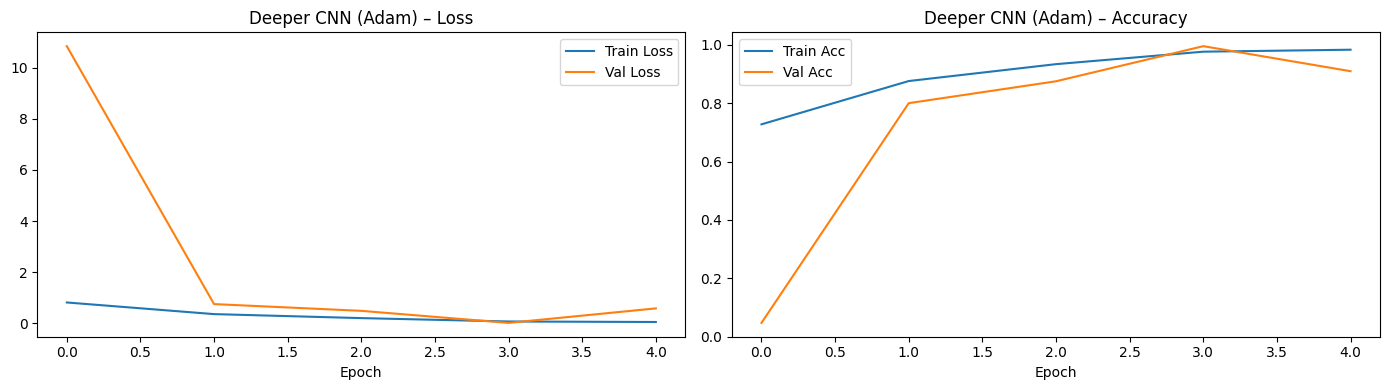


Deeper CNN (Adam) – Test Loss: 10.7561 | Test Accuracy: 0.0626
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step

Classification Report:
                      precision    recall  f1-score   support

Apple Granny Smith 1       0.00      0.00      0.00       164
         Apple Red 1       0.00      0.00      0.00       164
           Avocado 1       0.00      0.00      0.00       143
            Banana 1       0.00      0.00      0.00       166
         Blueberry 1       0.00      0.00      0.00       154
            Cherry 1       0.00      0.00      0.00       164
             Cocos 1       0.00      0.00      0.00       166
        Grape Blue 1       0.00      0.00      0.00       328
              Kiwi 1       0.00      0.00      0.00       156
             Lemon 1       0.00      0.00      0.00       164
             Mango 1       0.00      0.00      0.00       166
            Orange 1       0.00      0.00      0.00       160
            Papaya 1       0.00      0.00      0.00       164
 

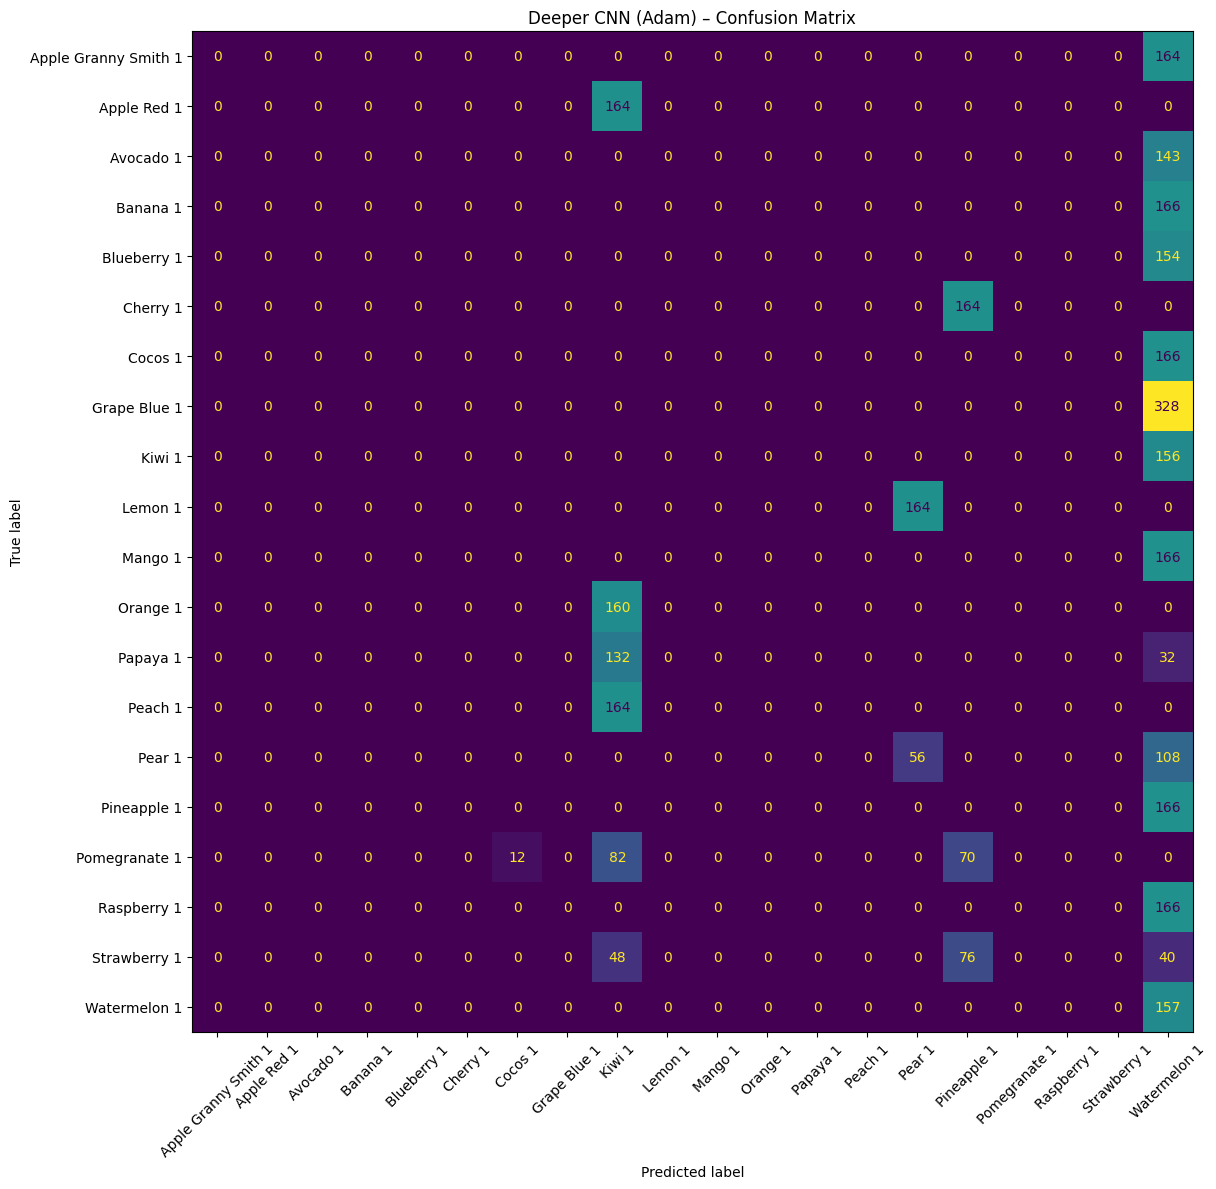

In [19]:
start = time.time()
deeper_history = deeper_model.fit(
    train_gen, validation_data=val_gen,
    epochs=30, callbacks=callbacks
)
deeper_time = time.time() - start
print(f'\nDeeper model training time: {deeper_time:.1f}s')

plot_history(deeper_history, 'Deeper CNN (Adam)')
deeper_acc = evaluate_model(deeper_model, test_gen, 'Deeper CNN (Adam)')

---
## PART A – Section 3: Optimizer Comparison (SGD vs Adam)

Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 39s 108ms/step - accuracy: 0.4172 - loss: 1.7726 - val_accuracy: 0.6188 - val_loss: 1.0971 - learning_rate: 0.0100
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.6607 - loss: 0.9758 - val_accuracy: 0.4822 - val_loss: 2.0650 - learning_rate: 0.0100
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7232 - loss: 0.7598
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
255/255 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.7432 - loss: 0.7108 - val_accuracy: 0.2392 - val_loss: 4.2665 - learning_rate: 0.0100
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.8551 - loss: 0.3995 - val_accuracy: 0.8062 - val_loss: 0.5963 - learning_rate: 0.0050
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.8907 - loss: 0.3157 - val_accuracy: 0.9048 - val_loss: 0.3336 - learning_rate: 0.0050
SGD training time: 120.3s


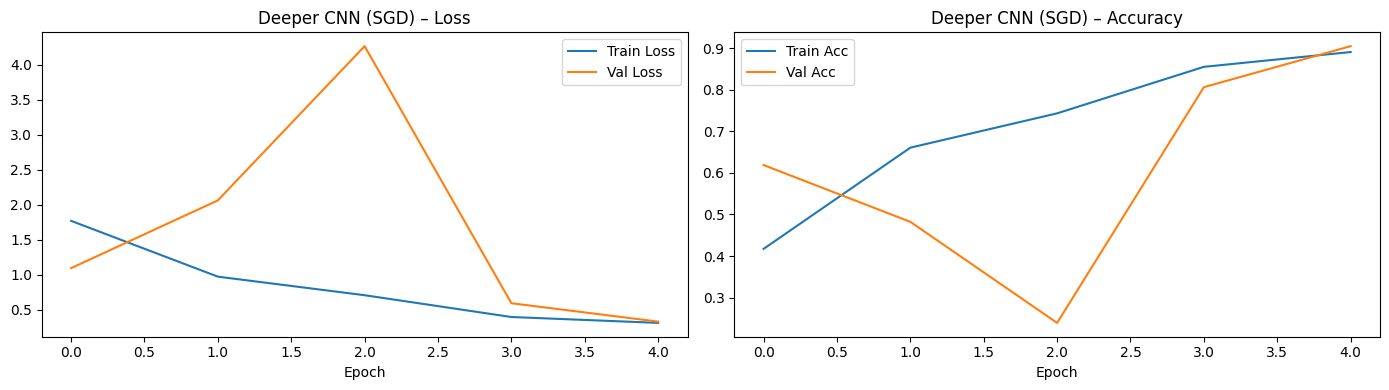


Deeper CNN (SGD) – Test Loss: 0.9106 | Test Accuracy: 0.6513
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step

Classification Report:
                      precision    recall  f1-score   support

Apple Granny Smith 1       0.71      1.00      0.83       164
         Apple Red 1       0.54      0.37      0.43       164
           Avocado 1       0.79      0.87      0.83       143
            Banana 1       1.00      0.61      0.76       166
         Blueberry 1       0.86      0.19      0.32       154
            Cherry 1       1.00      1.00      1.00       164
             Cocos 1       0.63      0.77      0.70       166
        Grape Blue 1       0.64      1.00      0.78       328
              Kiwi 1       0.42      0.10      0.16       156
             Lemon 1       0.15      0.07      0.09       164
             Mango 1       0.56      0.69      0.62       166
            Orange 1       0.50      1.00      0.66       160
            Papaya 1       0.85      0.82      0.83       164
   

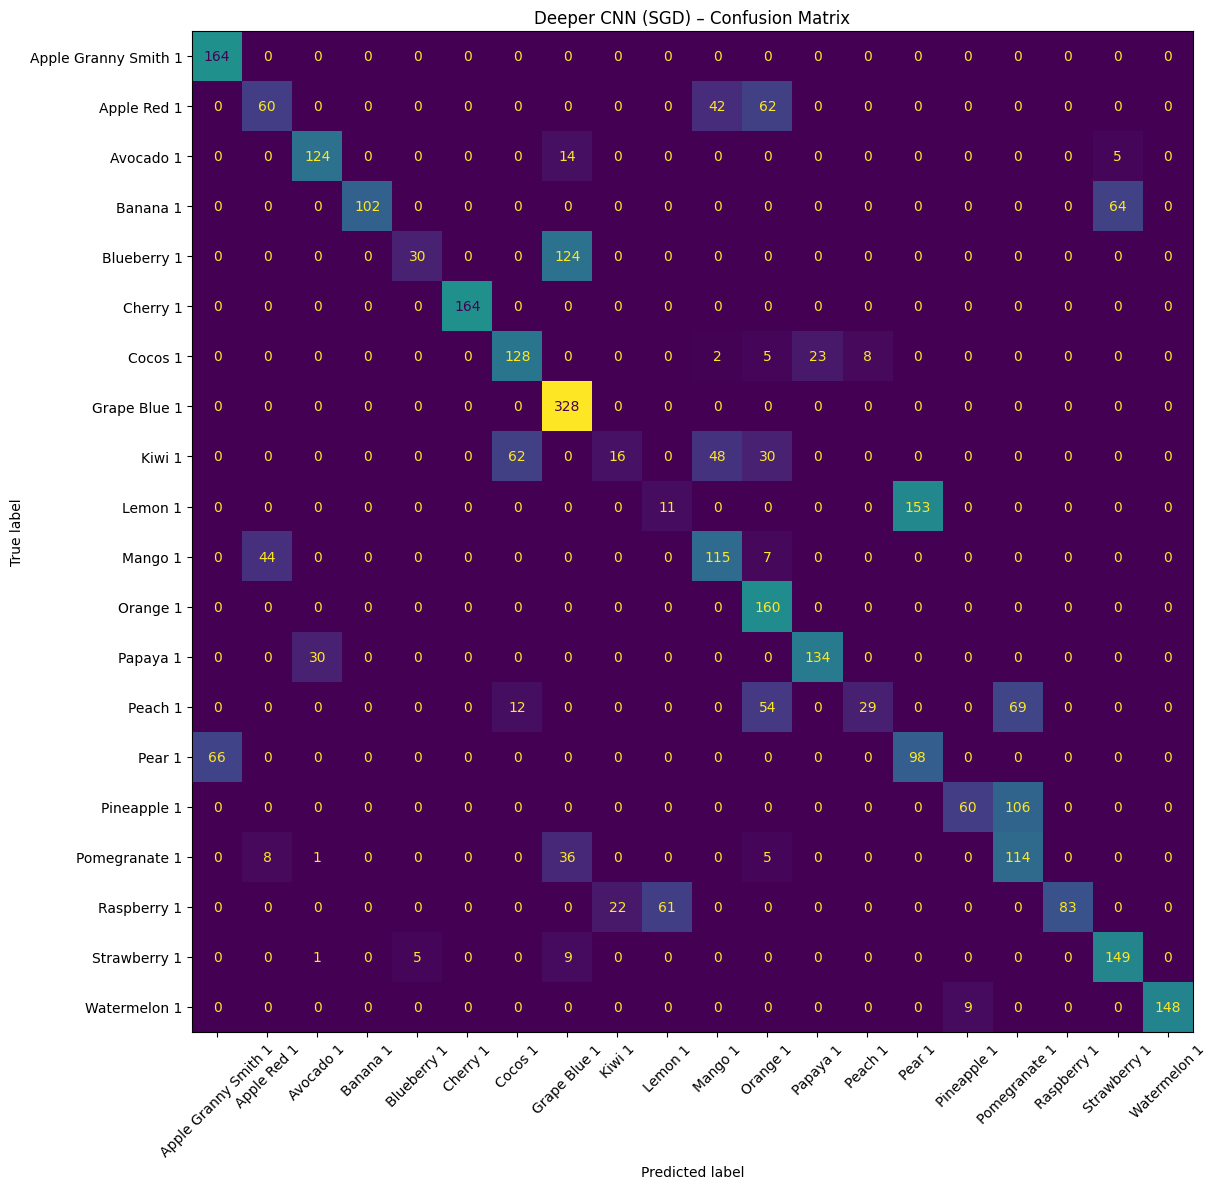

In [20]:
# Train with SGD
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
deeper_sgd = build_deeper_cnn(NUM_CLASSES, optimizer=sgd_optimizer)

start = time.time()
sgd_history = deeper_sgd.fit(
    train_gen, validation_data=val_gen,
    epochs=30, callbacks=callbacks
)
sgd_time = time.time() - start
print(f'SGD training time: {sgd_time:.1f}s')

plot_history(sgd_history, 'Deeper CNN (SGD)')
sgd_acc = evaluate_model(deeper_sgd, test_gen, 'Deeper CNN (SGD)')

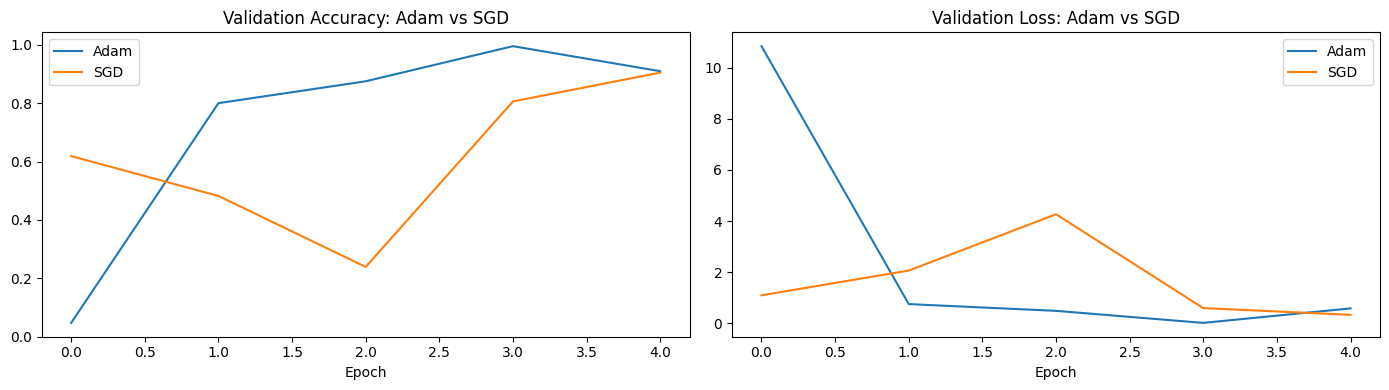

In [21]:
# Side-by-side optimizer comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(deeper_history.history['val_accuracy'], label='Adam')
axes[0].plot(sgd_history.history['val_accuracy'],    label='SGD')
axes[0].set_title('Validation Accuracy: Adam vs SGD')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(deeper_history.history['val_loss'], label='Adam')
axes[1].plot(sgd_history.history['val_loss'],    label='SGD')
axes[1].set_title('Validation Loss: Adam vs SGD')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## PART A – Section 4: Ablation Study (Remove Dropout)

Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - accuracy: 0.8583 - loss: 0.4216 - val_accuracy: 0.2041 - val_loss: 8.9188 - learning_rate: 0.0010
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.9473 - loss: 0.1567 - val_accuracy: 0.7406 - val_loss: 0.8827 - learning_rate: 0.0010
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9743 - loss: 0.0754
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
255/255 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.9738 - loss: 0.0789 - val_accuracy: 0.9191 - val_loss: 0.2326 - learning_rate: 0.0010
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.9972 - loss: 0.0108 - val_accuracy: 0.9995 - val_loss: 0.0038 - learning_rate: 5.0000e-04
Epoch 5/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.9947 - loss: 0.0174 - val_accuracy: 0.9926 - val_loss: 0.0231 - learning_rate: 5.0000e-04


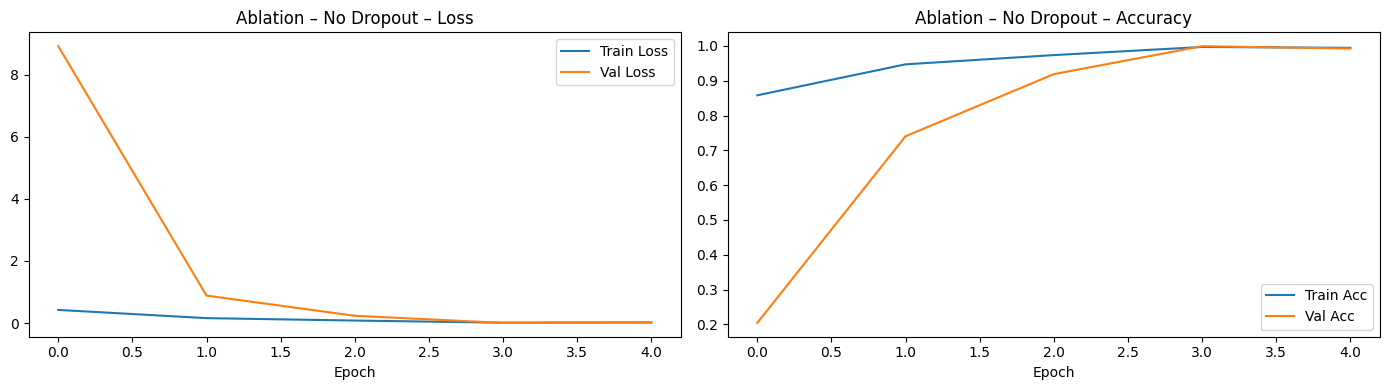


Ablation (No Dropout) – Test Loss: 9.0211 | Test Accuracy: 0.1586
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step

Classification Report:
                      precision    recall  f1-score   support

Apple Granny Smith 1       0.00      0.00      0.00       164
         Apple Red 1       0.00      0.00      0.00       164
           Avocado 1       0.00      0.00      0.00       143
            Banana 1       0.00      0.00      0.00       166
         Blueberry 1       0.00      0.00      0.00       154
            Cherry 1       0.00      0.00      0.00       164
             Cocos 1       1.00      0.02      0.05       166
        Grape Blue 1       0.00      0.00      0.00       328
              Kiwi 1       0.00      0.00      0.00       156
             Lemon 1       1.00      0.29      0.45       164
             Mango 1       0.00      0.00      0.00       166
            Orange 1       0.00      0.00      0.00       160
            Papaya 1       0.00      0.00      0.00       16

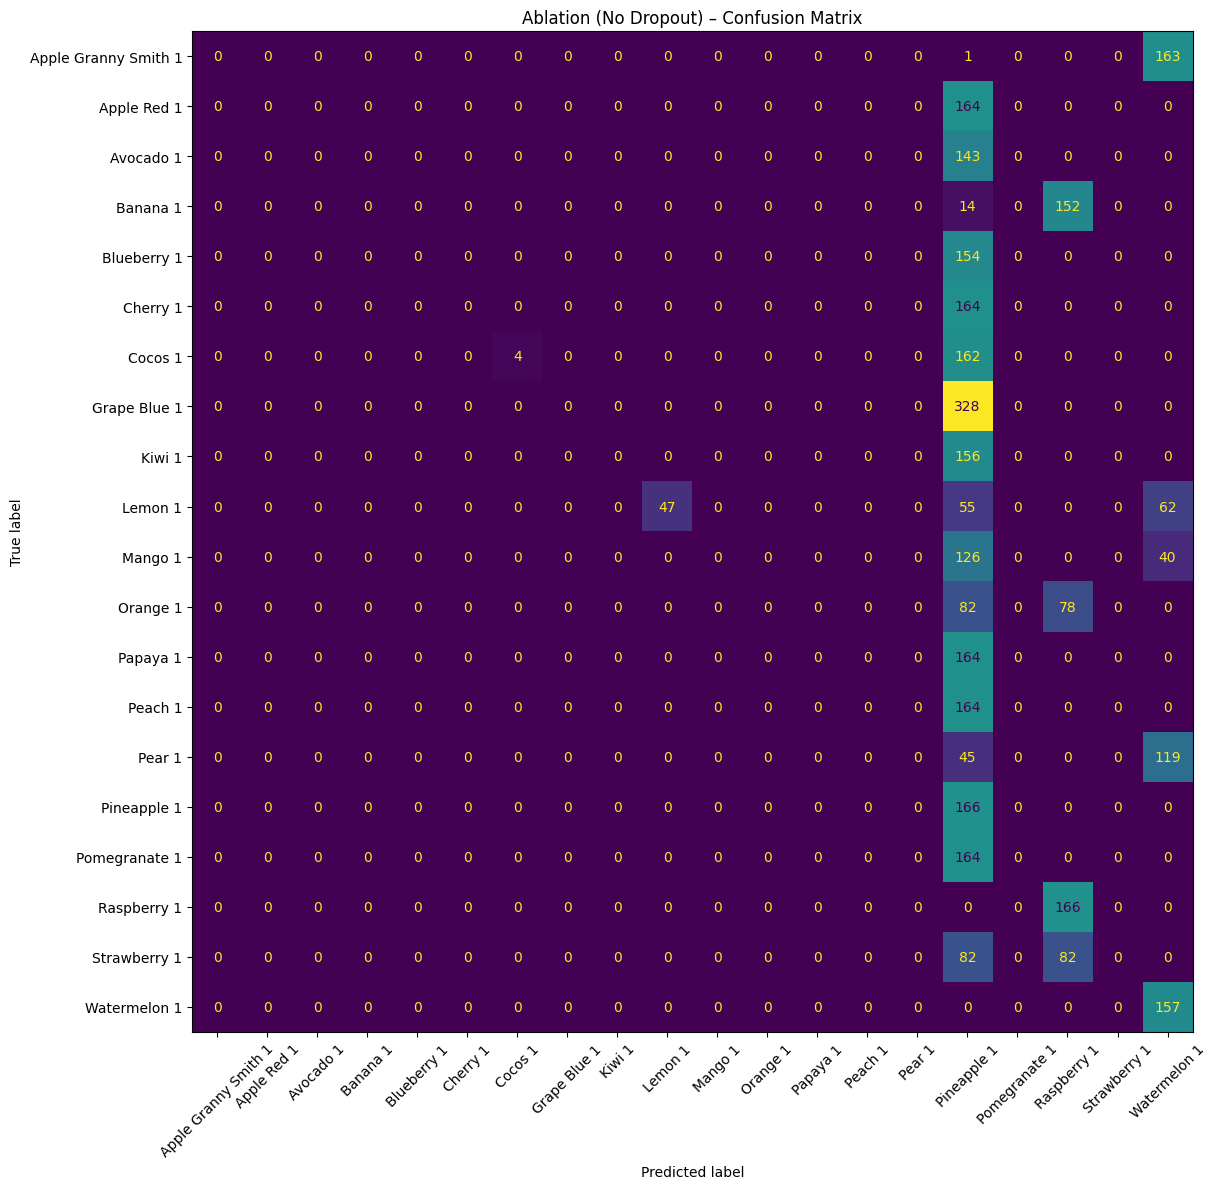

In [22]:
# Build deeper model WITHOUT dropout to see impact
def build_no_dropout_cnn(num_classes):
    model = models.Sequential([
        layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
        layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='NoDrop_CNN')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

ablation_model = build_no_dropout_cnn(NUM_CLASSES)
ablation_history = ablation_model.fit(
    train_gen, validation_data=val_gen,
    epochs=20, callbacks=callbacks
)
plot_history(ablation_history, 'Ablation – No Dropout')
ablation_acc = evaluate_model(ablation_model, test_gen, 'Ablation (No Dropout)')

---
## PART A – Section 5: Comparative Summary

                Model  Test Accuracy Train Time (s)
         Baseline CNN       0.989424     304.855794
    Deeper CNN (Adam)       0.062573     120.854722
     Deeper CNN (SGD)       0.651293     120.340541
Ablation (No Dropout)       0.158637            N/A


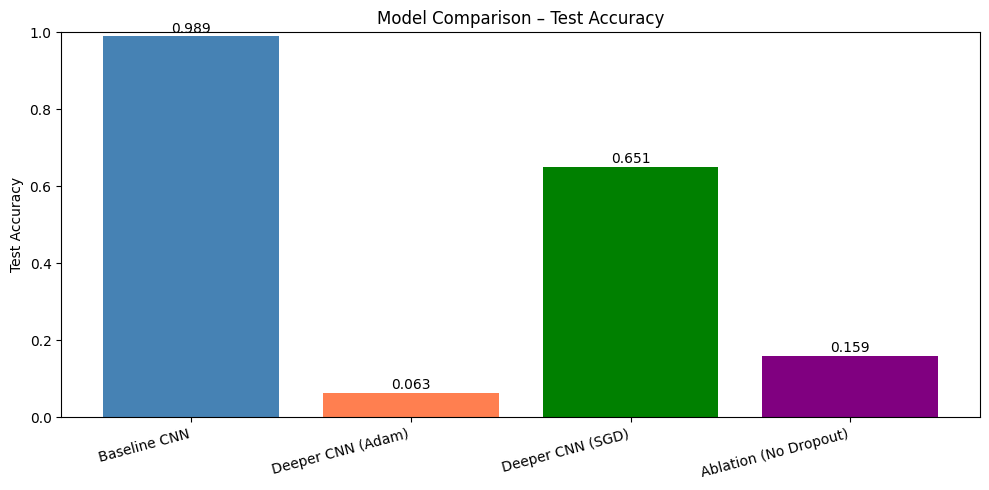

In [23]:
# Summary table
import pandas as pd

results = pd.DataFrame({
    'Model':        ['Baseline CNN', 'Deeper CNN (Adam)', 'Deeper CNN (SGD)', 'Ablation (No Dropout)'],
    'Test Accuracy': [baseline_acc,   deeper_acc,          sgd_acc,            ablation_acc],
    'Train Time (s)':[baseline_time,  deeper_time,         sgd_time,           'N/A']
})
print(results.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(results['Model'], results['Test Accuracy'], color=['steelblue','coral','green','purple'])
ax.set_ylim(0, 1)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison – Test Accuracy')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()

---
## PART B – Transfer Learning with MobileNetV2

In [24]:
# MobileNetV2 expects 96x96 minimum – use 96x96
IMG_SIZE_TL = (96, 96)

tl_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
tl_test_datagen = ImageDataGenerator(rescale=1./255)

tl_train_gen = tl_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)
tl_val_gen = tl_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
print('Transfer learning generators ready!')

Found 8143 images belonging to 20 classes.
Found 2028 images belonging to 20 classes.
Found 3404 images belonging to 20 classes.
Transfer learning generators ready!


In [25]:
# Load MobileNetV2 pre-trained on ImageNet, freeze base
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,      # Remove original 1000-class head
    weights='imagenet'
)
base_model.trainable = False  # Freeze convolutional base (Feature Extraction)

# Add custom classification head
inputs = keras.Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,396 (10.00 MB)

 Trainable params: 363,412 (1.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - accuracy: 0.9368 - loss: 0.2301 - val_accuracy: 0.9990 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 2/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9990 - loss: 0.0073 - val_accuracy: 0.9995 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 3/15
253/255 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9988 - loss: 0.0063
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
255/255 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9991 - loss: 0.0051 - val_accuracy: 0.9882 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 4/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9995 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 5/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9991 - loss: 0.0040 - val_accuracy: 0.9995 - val_loss: 0.0035 - learning_rate: 5.0000e-04
Phase 1 training time: 78.2s


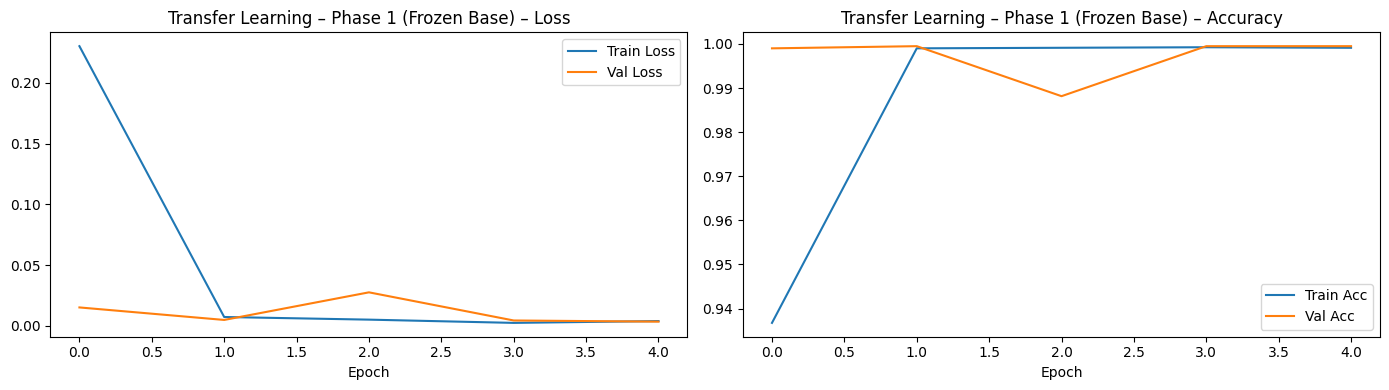

In [26]:
# Phase 1 – Feature Extraction (frozen base)
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
tl_history_phase1 = tl_model.fit(
    tl_train_gen, validation_data=tl_val_gen,
    epochs=15, callbacks=callbacks
)
tl_time_p1 = time.time() - start
print(f'Phase 1 training time: {tl_time_p1:.1f}s')
plot_history(tl_history_phase1, 'Transfer Learning – Phase 1 (Frozen Base)')

Epoch 1/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.7589 - loss: 0.8746 - val_accuracy: 0.9906 - val_loss: 0.0338 - learning_rate: 1.0000e-05
Epoch 2/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9779 - loss: 0.0999 - val_accuracy: 0.9975 - val_loss: 0.0166 - learning_rate: 1.0000e-05
Epoch 3/15
253/255 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9925 - loss: 0.0493
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
255/255 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9929 - loss: 0.0451 - val_accuracy: 0.9990 - val_loss: 0.0101 - learning_rate: 1.0000e-05
Epoch 4/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9942 - loss: 0.0343 - val_accuracy: 0.9995 - val_loss: 0.0047 - learning_rate: 5.0000e-06
Epoch 5/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9951 - loss: 0.0262 - val_accuracy: 0.9995 - val_loss: 0.0029 - learning_rate: 5.0000e-06
Phase 2 (fine-tuning) time: 67.6s


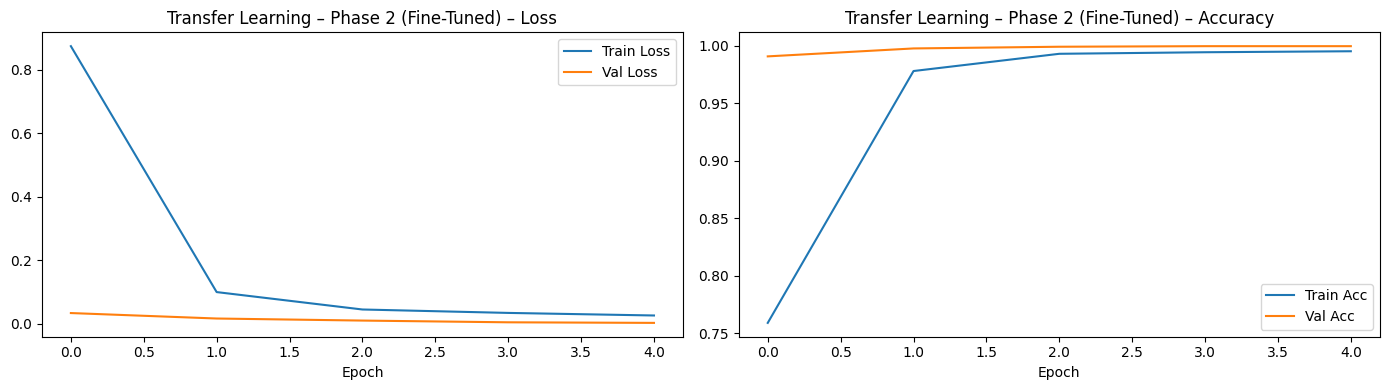

In [27]:
# Phase 2 – Fine-Tuning (unfreeze last 30 layers)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # Very low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
tl_history_phase2 = tl_model.fit(
    tl_train_gen, validation_data=tl_val_gen,
    epochs=15, callbacks=callbacks
)
tl_time_p2 = time.time() - start
print(f'Phase 2 (fine-tuning) time: {tl_time_p2:.1f}s')
plot_history(tl_history_phase2, 'Transfer Learning – Phase 2 (Fine-Tuned)')


MobileNetV2 Transfer Learning – Test Loss: 0.0511 | Test Accuracy: 0.9794
107/107 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step

Classification Report:
                      precision    recall  f1-score   support

Apple Granny Smith 1       0.91      1.00      0.95       164
         Apple Red 1       1.00      0.85      0.92       164
           Avocado 1       0.98      1.00      0.99       143
            Banana 1       1.00      0.99      1.00       166
         Blueberry 1       1.00      1.00      1.00       154
            Cherry 1       1.00      0.95      0.97       164
             Cocos 1       1.00      0.98      0.99       166
        Grape Blue 1       0.98      1.00      0.99       328
              Kiwi 1       1.00      1.00      1.00       156
             Lemon 1       0.91      1.00      0.95       164
             Mango 1       1.00      1.00      1.00       166
            Orange 1       1.00      1.00      1.00       160
            Papaya 1       0.99      1.00      0.99

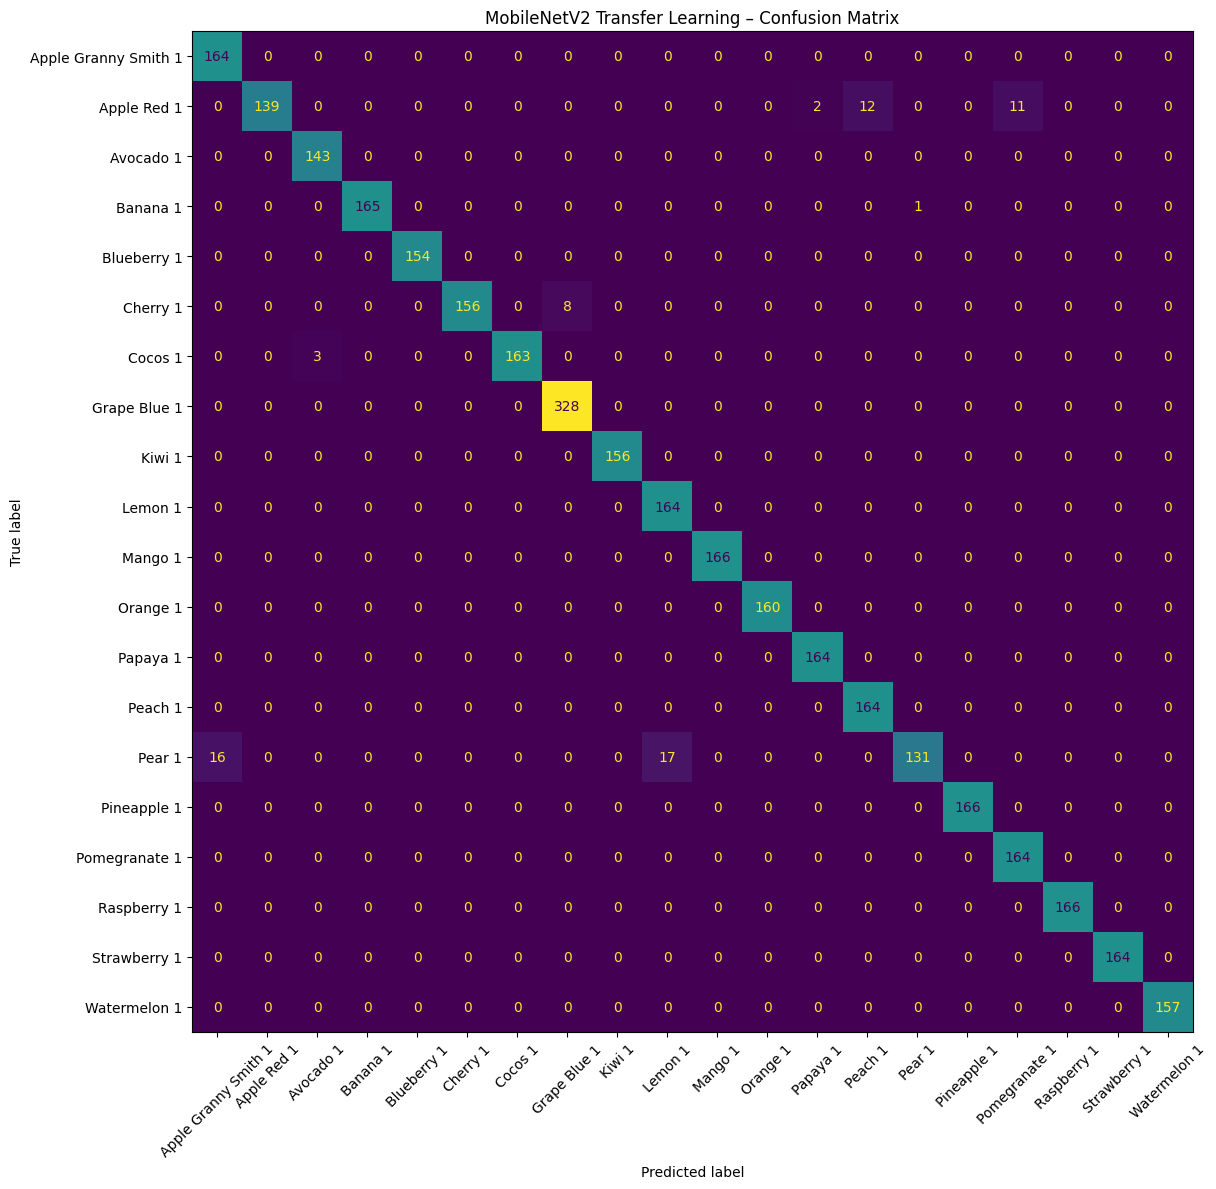

In [28]:
# Evaluate Transfer Learning model
tl_acc = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 Transfer Learning')


===== FINAL MODEL COMPARISON =====
            Model  Test Accuracy
     Baseline CNN       0.989424
Deeper CNN (Adam)       0.062573
 Deeper CNN (SGD)       0.651293
   MobileNetV2 TL       0.979436


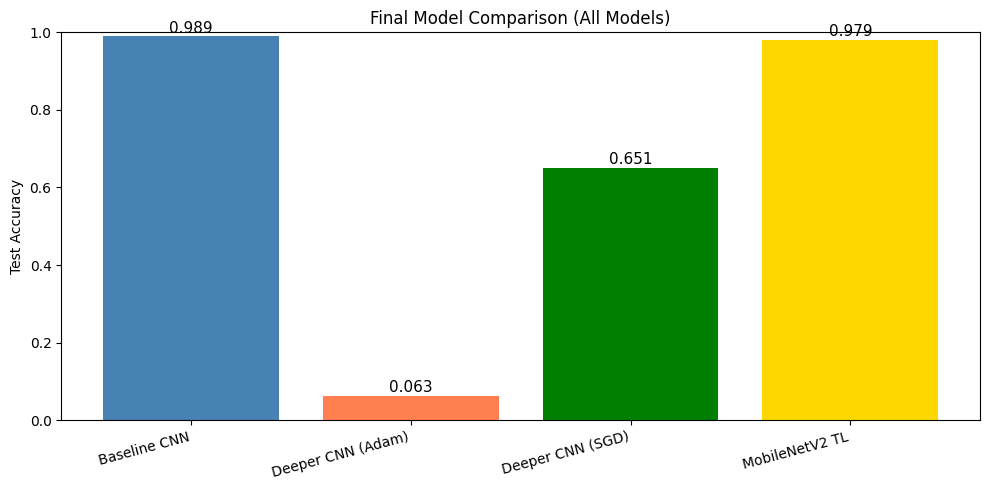

In [29]:
# Final comparison including Transfer Learning
all_results = pd.DataFrame({
    'Model':         ['Baseline CNN', 'Deeper CNN (Adam)', 'Deeper CNN (SGD)', 'MobileNetV2 TL'],
    'Test Accuracy': [baseline_acc,   deeper_acc,          sgd_acc,            tl_acc]
})
print('\n===== FINAL MODEL COMPARISON =====')
print(all_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(all_results['Model'], all_results['Test Accuracy'],
              color=['steelblue','coral','green','gold'])
ax.set_ylim(0, 1)
ax.set_ylabel('Test Accuracy')
ax.set_title('Final Model Comparison (All Models)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=11)
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()